In [90]:
%reload_ext autoreload
%autoreload 2

import sys

import anndata
import cassiopeia as cas
import colorcet as cc
import matplotlib.pyplot as plt
import mplscience
import numpy as np
import pandas as pd
import pickle as pic
import scanpy as sc
import squidpy as sq
import seaborn as sns
import tqdm

from IPython.display import Image

SPATIAL_PACKAGE="/path/to/spatial/analysis/package"
DATA_DIR="/path/to/kpspatial/dataset/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import target_site_utilities, spatial_utilities, differential_expression, colors

## Figure 2a

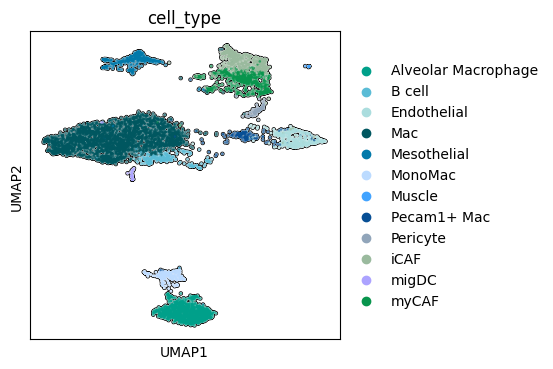

In [13]:
adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/slidetags_immune.h5ad')

adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
# adata_spatial.uns['CellType_Remapped_colors'] = new_color_palette

fig = plt.figure(figsize=(4,4))
ax = plt.gca()
sc.pl.umap(adata, color='cell_type', add_outline=True, ax=ax, show=False)
plt.show()

### Extended Data Figure 4a

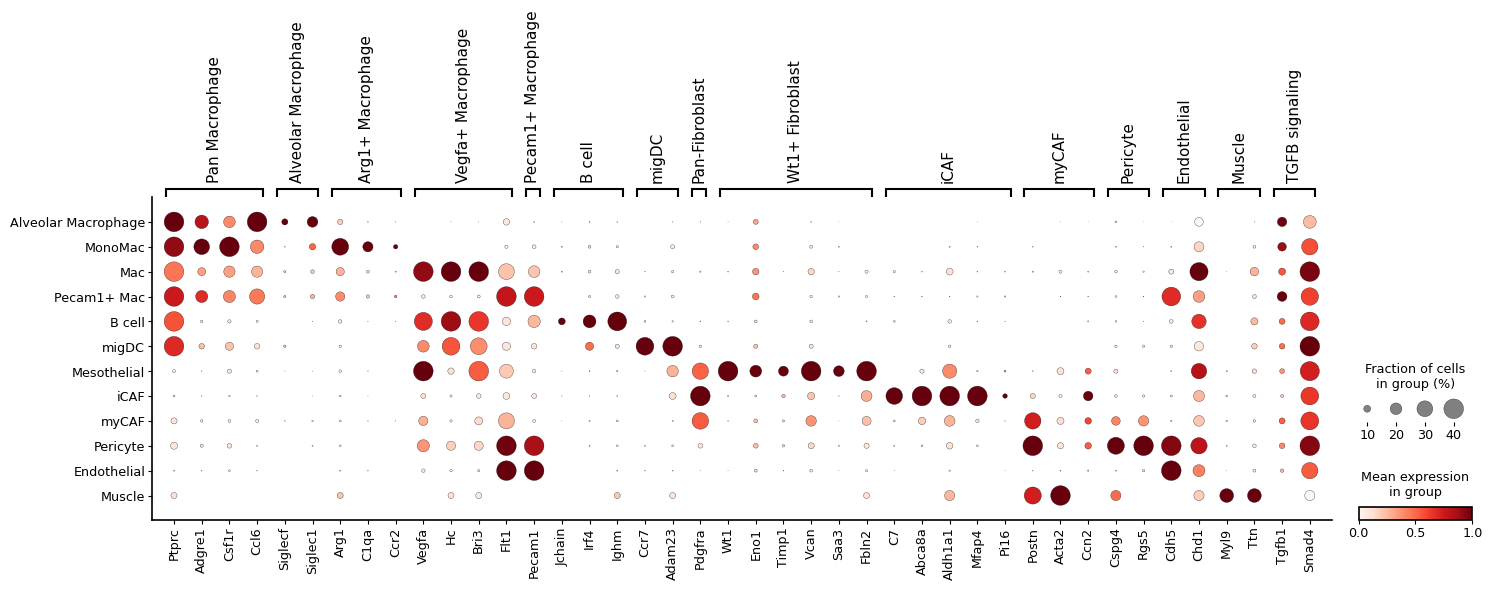

In [3]:
adata_spatial_raw = adata.raw.to_adata()
adata_spatial_raw.layers['counts'] = adata_spatial_raw.X.copy()
adata_spatial_raw.layers["logged"] = adata_spatial_raw.X.copy()

sc.pp.normalize_total(adata_spatial_raw, target_sum=1e6, layer='logged')
sc.pp.log1p(adata_spatial_raw, layer='logged')

marker_genes = {
                'Pan Macrophage': ['Ptprc', 'Adgre1', 'Csf1r', 'Ccl6'],
                'Alveolar Macrophage': ['Siglecf', 'Siglec1'],
                'Arg1+ Macrophage': ['Arg1', 'C1qa', 'Ccr2'],
                'Vegfa+ Macrophage': ['Vegfa', 'Hc', 'Bri3', 'Flt1'],
                'Pecam1+ Macrophage': ['Pecam1'],
                'B cell': ['Jchain', 'Irf4', 'Ighm'],
                'migDC': ['Ccr7', 'Adam23'],
                'Pan-Fibroblast': ['Pdgfra'],
                'Wt1+ Fibroblast': ['Wt1', 'Eno1', 'Timp1', 'Vcan', 'Saa3', 'Fbln2'],
                'iCAF': ['C7', 'Abca8a', 'Aldh1a1', 'Mfap4', 'Pi16'],
                'myCAF': ['Postn', 'Acta2', 'Ccn2'],
                'Pericyte': ['Cspg4', 'Rgs5'],
                'Endothelial': ['Cdh5', 'Chd1'],
                'Muscle': ['Myl9', 'Ttn'],
                'TGFB signaling': ['Tgfb1', 'Smad4'],
}

cell_type_ordering = ['Alveolar Macrophage', 'MonoMac', 'Mac', 'Pecam1+ Mac', 'B cell', 'migDC','Mesothelial', 'iCAF', 'myCAF',  'Pericyte', 'Endothelial',  'Muscle']

with mplscience.style_context():
    sc.pl.dotplot(adata_spatial_raw,
                  marker_genes,
                  groupby='CellType_Remapped',
                  dendrogram=False,
                  layer='logged',
                  standard_scale='var',
                  dot_max=0.4,
                  categories_order=cell_type_ordering, show=False)
    plt.show()

### Figure 2b

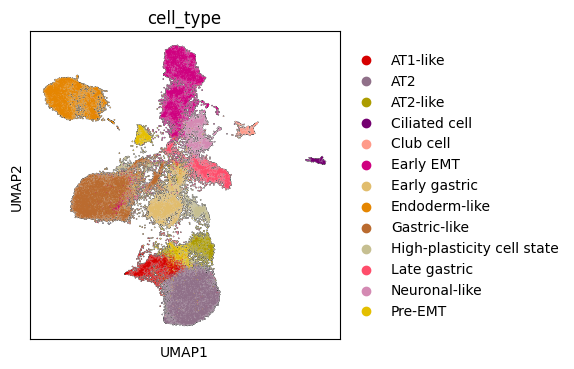

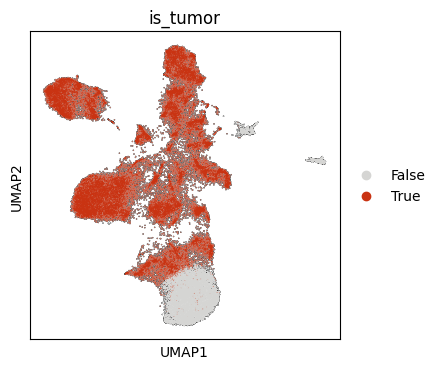

In [2]:
adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/slidetags_tumor.h5ad')

h = plt.figure(figsize=(4,4))
ax = plt.gca()
sc.pl.umap(adata,
           color='cell_type',
           frameon=True,
           add_outline=True,
           show=False,
           ax=ax
          )
plt.show()

tumor_states = ['AT2-like', 'AT1-like', 'Early EMT', 'Endoderm-like', 'Early gastric', 'Gastric-like', 'High-plasticity cell state', 'Late gastric', 'Neuronal-like', 'Pre-EMT']
adata.obs['is_tumor'] = "False"
adata.obs.loc[adata.obs['cell_type'].isin(tumor_states), 'is_tumor'] = 'True'

adata.uns['is_tumor_colors'] = ["#D5D5D3", "#C93312"]


h = plt.figure(figsize=(4,4))
ax = plt.gca()
sc.pl.umap(adata,
           color='is_tumor',
           frameon=True,
           add_outline=True,
           show=False,
           cmap='Reds',
           ax=ax
          )

plt.show()

### Figure 2c

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


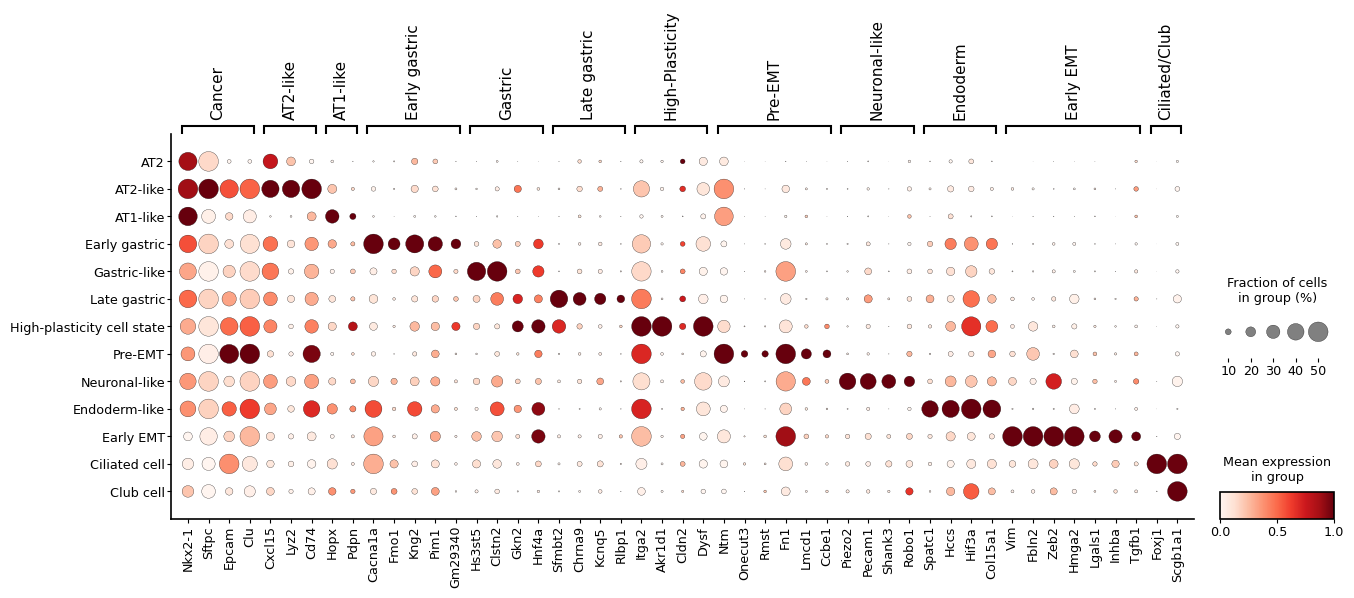

In [5]:
cancer = ['Nkx2-1', 'Sftpc', 'Epcam', 'Clu']
at2_programs = ['Cxcl15', 'Lyz2', 'Cd74']
at1_programs = ['Hopx', 'Pdpn']
early_gastric = ['Cacna1a', 'Fmo1', 'Kng2', 'Pim1', 'Gm29340']
gastric_like = ['Hs3st5', 'Clstn2', 'Gkn2', 'Hnf4a', ]
late_gastric = ['Sfmbt2', 'Chrna9', 'Kcnq5', 'Rlbp1']
endoderm_like = ['Spatc1', 'Hccs', 'Hif3a', 'Col15a1']
high_plasticity = ['Itga2', 'Akr1d1', 'Cldn2', 'Dysf']
pre_emt = ['Ntm', 'Onecut3', 'Rmst', 'Fn1', 'Lmcd1', 'Ccbe1']
early_emt = ['Vim', 'Fbln2', 'Zeb2', 'Hmga2', 'Lgals1', 'Inhba', 'Tgfb1']
club_cell = ['Scgb1a1']
ciliated_cell = ['Foxj1']
neuronal_like = ['Piezo2', 'Pecam1', 'Shank3', 'Robo1']

categories_order = ['AT2', 'AT2-like', 'AT1-like', 'Early gastric', 'Gastric-like', 'Late gastric', 'High-plasticity cell state',
                    'Pre-EMT', 'Neuronal-like', 'Endoderm-like', 'Early EMT', 'Ciliated cell', 'Club cell']


adata_raw = adata.raw.to_adata()
adata_raw.layers["counts"] = adata_raw.X.copy() # preserve counts
adata_raw.layers['logged'] = adata_raw.X.copy()

target_sum = np.median(np.array(adata_raw.X.sum(axis=1)))
sc.pp.normalize_total(adata_raw, target_sum=target_sum)
sc.pp.log1p(adata_raw, layer='logged')

adata_raw.layers['scaled'] = adata_raw.layers['logged']
sc.pp.scale(adata_raw, layer='scaled', max_value=10)

with mplscience.style_context():
    sc.pl.dotplot(adata_raw,
                  var_names={
                             'Cancer': cancer,
                             'AT2-like': at2_programs,
                             'AT1-like': at1_programs,
                             'Early gastric': early_gastric,
                             'Gastric': gastric_like,
                             'Late gastric': late_gastric,
                             'High-Plasticity': high_plasticity,
                             'Pre-EMT': pre_emt,
                             'Neuronal-like': neuronal_like,
                             'Endoderm': endoderm_like,
                             'Early EMT': early_emt,
                             'Ciliated/Club': ciliated_cell + club_cell,
                  },
                  categories_order=categories_order,
                  groupby='cell_type',
                  standard_scale='var',
                  layer='counts',
                  dot_max=0.5,
                  figsize=(15,5),
                  dendrogram=False,
                  show=False)

    plt.show()

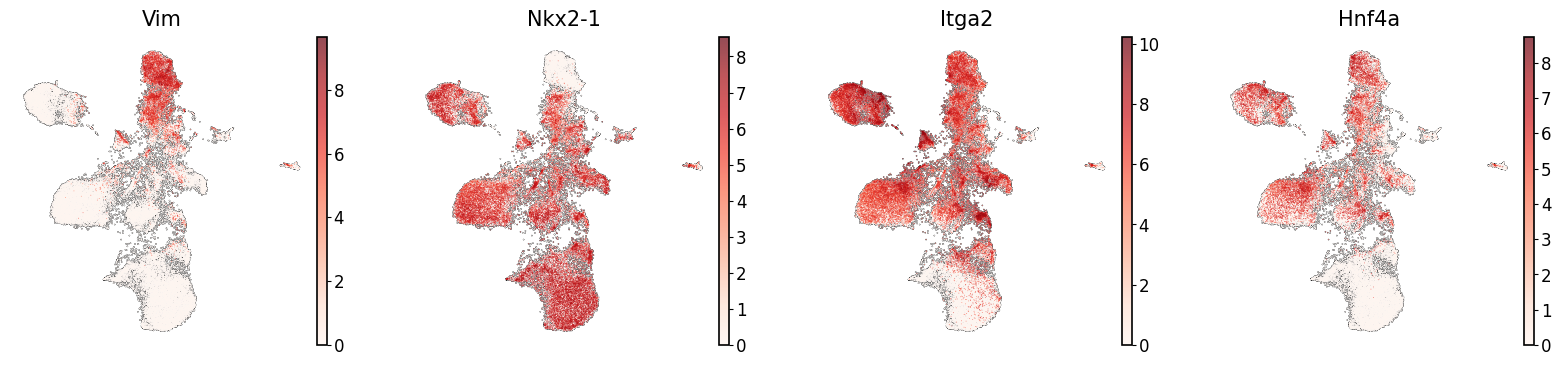

In [7]:
with mplscience.style_context():
    sc.pl.umap(adata_raw,
                   color=['Vim', 'Nkx2-1', 'Itga2', 'Hnf4a'],
                   frameon=False,
                   add_outline=True,
                   layer='logged',
                   cmap='Reds',
                   show=False,
                  )
    plt.show()


### Figure 2d

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


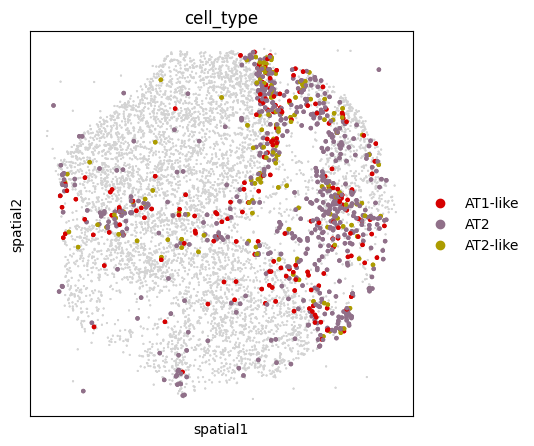

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


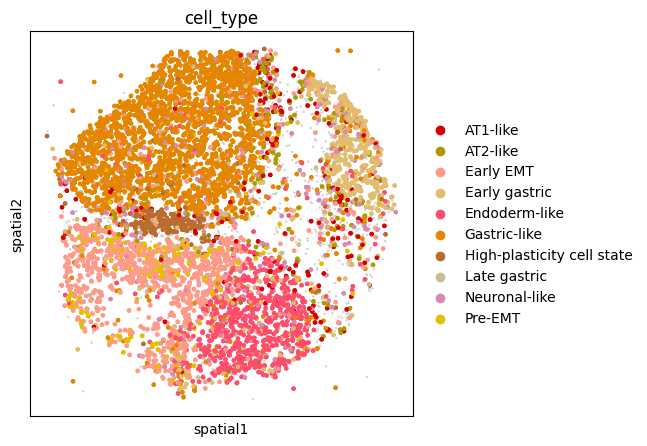

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


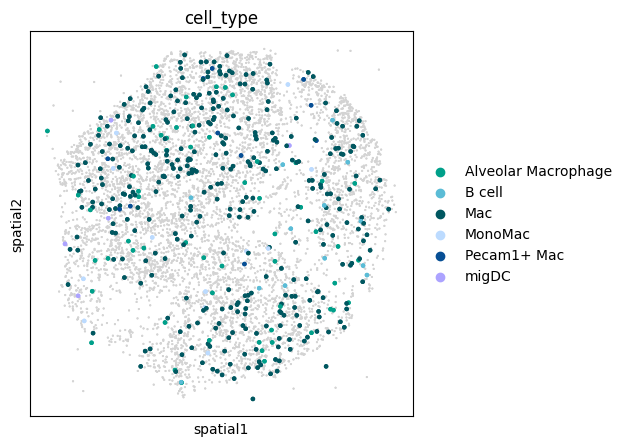

In [32]:
LAYER, PUCK = 'Layer3', 'Puck1'

adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/adata_slidetags.{LAYER}.{PUCK}.h5ad')

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
adata.obs['dummy'] = np.nan
sq.pl.spatial_scatter(adata, color='dummy', size=1, shape=None, ax=ax, na_color='lightgray', colorbar=False)
sq.pl.spatial_scatter(adata, color="cell_type", size=20, groups=['AT2-like', 'AT1-like', 'AT2'], shape=None, ax=ax, outline=False)
plt.gca().invert_yaxis()
plt.show()

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
adata.obs['dummy'] = np.nan
sq.pl.spatial_scatter(adata, color='dummy', size=1, shape=None, ax=ax, na_color='lightgray', colorbar=False)
sq.pl.spatial_scatter(adata, color="cell_type", size=20,
                      groups=['AT1-like',
                          'AT2-like',
                          'Early EMT',
                          'Early gastric',
                          'Endoderm-like',
                          'Gastric-like',
                          'High-plasticity cell state',
                          'Late gastric',
                          'Neuronal-like',
                          'Pre-EMT'], 
                        shape=None, ax=ax, outline=False)
plt.gca().invert_yaxis()
plt.show()

fig = plt.figure(figsize=(5,5))
ax = plt.gca()
adata.obs['dummy'] = np.nan
sq.pl.spatial_scatter(adata, color='dummy', size=1, shape=None, ax=ax, na_color='lightgray', colorbar=False)
sq.pl.spatial_scatter(adata, color="cell_type", size=20, groups=['Mac',
                                                                 'MonoMac',
                                                                 'Alveolar Macrophage',
                                                                 'B cell',
                                                                 'Pecam1+ Mac',
                                                                'migDC'],
                      shape=None, ax=ax, outline=False)
plt.gca().invert_yaxis()
# plt.savefig(f'../figures/slidetag_{LAYER}_{PUCK}.immune.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot signatures vs KPTracer dataset

In [98]:
slidetags_tumor_adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/slidetags_tumor.h5ad')
slidetags_tumor_adata.obs['cell_type'] = slidetags_tumor_adata.obs['cell_type'].astype(str)

slidetags_tumor_adata.obs.loc[(slidetags_tumor_adata.obs['cell_type'] == 'AT2'), 'cell_type'] = 'AT2-like'

tumor_de = differential_expression.differential_expression(adata_path="",
                                                            cluster_labels="cell_type",
                                                            output_path=None,
                                                            adata=slidetags_tumor_adata,
                                                            de_method='wilcoxon',
                                                            layer='counts',
                                                            n_top_genes=100)

tumor_de.to_csv('./data/tumor_differential_expression.tsv', sep='\t')

In [97]:
tumor_de.head(5)

,clusterAT1-like_names,clusterAT1-like_logfoldchanges,clusterAT1-like_pvals_adj,clusterAT1-like_percent_expressed,clusterAT1-like_auroc,clusterAT1-like_auprc,clusterAT2_names,clusterAT2_logfoldchanges,clusterAT2_pvals_adj,clusterAT2_percent_expressed,...,clusterNeuronal-like_pvals_adj,clusterNeuronal-like_percent_expressed,clusterNeuronal-like_auroc,clusterNeuronal-like_auprc,clusterPre-EMT_names,clusterPre-EMT_logfoldchanges,clusterPre-EMT_pvals_adj,clusterPre-EMT_percent_expressed,clusterPre-EMT_auroc,clusterPre-EMT_auprc
0,Col4a4,inf,0.0,0.963543,0.930103,0.611517,Hc,inf,0.0,0.930902,...,0.0,0.814883,0.761594,0.177835,Ntm,inf,0.0,0.721405,0.809399,0.324229
1,Col4a3,inf,0.0,0.953299,0.917486,0.538831,Nkd1,inf,0.0,0.945267,...,0.0,0.594084,0.758309,0.344701,Tenm4,inf,0.0,0.748775,0.775803,0.169803
2,Lmo7,NaN,0.0,0.957517,0.881509,0.314129,Mecom,NaN,0.0,0.994033,...,0.0,0.523025,0.748807,0.408578,Mecom,NaN,0.0,0.986928,0.758866,0.070931
3,Nebl,NaN,0.0,0.934318,0.868809,0.352524,Ank3,NaN,0.0,0.997937,...,0.0,0.792620,0.726227,0.216122,Pmepa1,inf,0.0,0.812908,0.758290,0.139013
4,Qk,inf,0.0,0.936125,0.867066,0.404456,Pde4d,NaN,0.0,0.989982,...,0.0,0.476060,0.725479,0.332037,Clu,NaN,0.0,0.796569,0.756704,0.131815


In [65]:
tumor_de = pd.read_csv('./data/tumor_differential_expression.tsv', sep='\t', index_col = 0)

program_to_genes = {}
for program in slidetags_tumor_adata.obs['cell_type'].unique():

    sub_de = tumor_de[[f'cluster{program}_names', f'cluster{program}_logfoldchanges',
                       f'cluster{program}_pvals_adj', f'cluster{program}_auroc']]
    sub_de.columns = ['names', 'lfc', 'pvals', 'auroc']

    genes = sub_de.loc[(sub_de['lfc'] > 1) & (sub_de['pvals'] <= 0.01) & (sub_de['auroc'] > 0.6), 'names']
    program_to_genes[program] = genes

View of AnnData object with n_obs × n_vars = 60334 × 3806
    obs: 'TS_captured', 'TS_UMI', 'TS_n_intbcs', 'lane', 'tumor', 'ES_clone', 'mouse', 'batch', 'is_tumor', 'TS_percent_cut', 'cell_type', 'source', 'n_counts', '_scvi_batch', '_scvi_labels', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colormap', 'cell_type_colors', 'hvg', 'is_tumor_colors', 'leiden', 'leiden_0.4_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_53310/1212544618.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tumor_celltype_programs.groupby('cell_type').agg({p: 'mean' for p in program_names}),


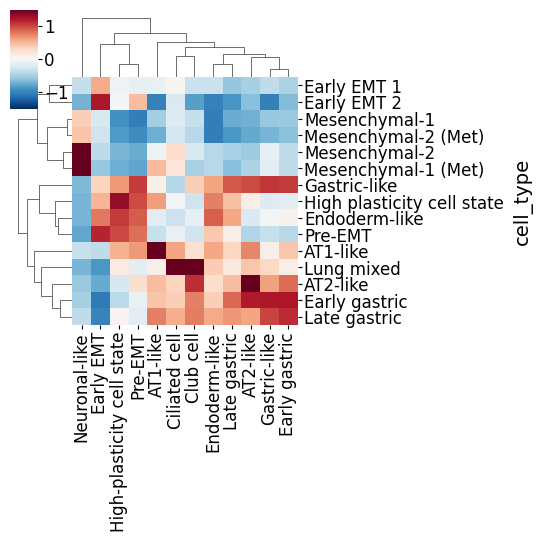

In [84]:

adata_original = sc.read_h5ad(f"{DATA_DIR}/KP_2022/adata_nt_combined.h5ad")
adata_original = adata_original[adata_original.obs['is_tumor'] == 'True']

print(adata_original)

adata_raw_original = adata_original.raw.to_adata()

adata_raw_original.layers["counts"] = adata_raw_original.X.copy() # preserve counts
adata_raw_original.layers['logged'] = adata_raw_original.X.copy()

target_sum = np.median(np.array(adata_raw_original.X.sum(axis=1)))
sc.pp.normalize_total(adata_raw_original, target_sum=target_sum)
sc.pp.log1p(adata_raw_original, layer='logged')

adata_raw_original.layers['scaled'] = adata_raw_original.layers['logged']
sc.pp.scale(adata_raw_original, layer='scaled', max_value=10)


for program_name in program_to_genes:
    program = program_to_genes[program_name]
    sc.tl.score_genes(adata_raw_original, program, ctrl_size=len(program), n_bins=30, score_name=program_name, use_raw=False)
    adata_raw_original.obs[program_name] = (adata_raw_original.obs[program_name] - adata_raw_original.obs[program_name].mean()) / adata_raw_original.obs[program_name].std()

program_names = list(program_to_genes.keys())

tumor_celltype_programs = adata_raw_original.obs.loc[:, ['cell_type'] + program_names]
with mplscience.style_context():
    sns.clustermap(
        tumor_celltype_programs.groupby('cell_type').agg({p: 'mean' for p in program_names}),
        cmap='RdBu_r',
        row_cluster=True,
        col_cluster=True,
        figsize=(5.5,5.5),
        # z_score=1,
        vmin=-1.5,
        vmax=1.5,
    )
    plt.show()

### Extended Data Figure 4e

In [91]:
samples = [('Layer1', 'Puck1'),
           ('Layer2', 'Puck1'),
           ('Layer3', 'Puck1'),
           ('Layer3', 'Puck2'),
           ('Layer4', 'Puck1')]

adatas_to_merge = []
for sample in samples:
    LAYER, PUCK = sample

    _adata = sc.read_h5ad(f'{DATA_DIR}/slidetags/expression/adata_slidetags.{LAYER}.{PUCK}.h5ad')
    
    # clean up
    cell_type_abundances = _adata.obs['cell_type'].value_counts()
    cell_types_to_keep = cell_type_abundances[cell_type_abundances >= 5].index.values
    _adata = _adata[_adata.obs['cell_type'].isin(cell_types_to_keep),:]

    tree = pic.load(open(f'{DATA_DIR}/slidetags/trees/{PUCK}_{LAYER}_hybrid.pkl', 'rb'))    
    
    tree.remove_leaves_and_prune_lineages(np.setdiff1d(tree.leaves, _adata.obs_names))
    
    _adata.obs['tumor'] = 'False'
    _adata.obs.loc[tree.leaves, 'tumor'] = 'True'
    _adata.obs['library_id'] = f'{LAYER}_{PUCK}'
        
    print(f"Read in tree with {len(tree.leaves)} leaves ({round(len(tree.leaves) / _adata.shape[0] * 100, 3)}% of all spots).")
    
    adatas_to_merge.append(_adata)

adata_merged = sc.concat(adatas_to_merge)

/tmp/ipykernel_53310/1179554329.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  _adata.obs['tumor'] = 'False'


Read in tree with 2373 leaves (19.229% of all spots).


/tmp/ipykernel_53310/1179554329.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  _adata.obs['tumor'] = 'False'


Read in tree with 832 leaves (8.298% of all spots).


/tmp/ipykernel_53310/1179554329.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  _adata.obs['tumor'] = 'False'


Read in tree with 1642 leaves (22.645% of all spots).


/tmp/ipykernel_53310/1179554329.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  _adata.obs['tumor'] = 'False'


Read in tree with 277 leaves (6.573% of all spots).


/tmp/ipykernel_53310/1179554329.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  _adata.obs['tumor'] = 'False'


Read in tree with 828 leaves (11.291% of all spots).


100%|██████████| 5/5 [00:02<00:00,  2.03it/s]


<Figure size 600x300 with 0 Axes>

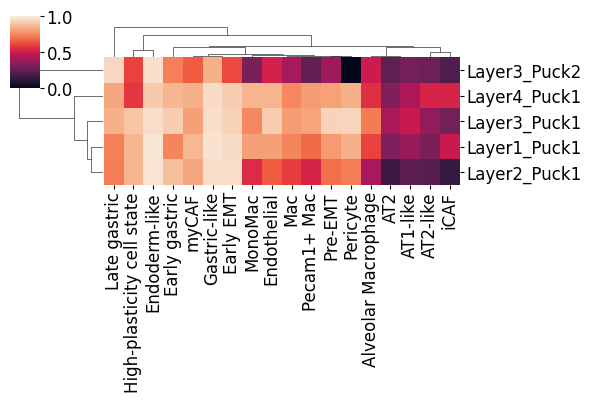

In [95]:
# compute frequency within and without tumor

cell_types = ['AT2', 'AT2-like', 'AT1-like', 'High-plasticity cell state', 'Early gastric', 'Gastric-like', 'Endoderm-like', 'Late gastric', 'Pre-EMT', 'Early EMT',
             'Mac', 'MonoMac', 'Alveolar Macrophage', 'Pecam1+ Mac', 'iCAF', 'myCAF', 'Endothelial', 'Pericyte']


freq_df = pd.DataFrame(index=adata_merged.obs['library_id'].unique(), columns=cell_types)

for sample in tqdm.tqdm(adata_merged.obs['library_id'].unique()):

    adata_sub = adata_merged[adata_merged.obs['library_id'] == sample]
    for cell_type in cell_types:

        cells = adata_sub[adata_sub.obs['cell_type'] == cell_type].obs_names
        tumor_cells = adata_sub[adata_sub.obs['tumor_id'] != 'non-tumor'].obs_names

        freq_df.loc[sample, cell_type] = len(np.intersect1d(cells, tumor_cells)) / max(1, len(cells))

with mplscience.style_context():
    h = plt.figure(figsize=(6, 3))
    sns.clustermap(data=freq_df.astype(float), cmap='rocket', figsize=(6, 4), row_cluster=True, metric='correlation', vmin=0, vmax=1.0)
    plt.show()
